# NRT threshold selection

Chooses the probability threshold of the near real time rule, from the per-acquisition
scores written by `nrt_scores.py`. It answers two questions: does the score separate the
acquisitions before an event from those after it, and does the joint mode separate them
better than the optical one.

It does **not** measure timeliness. Applying the rule to each polygon and comparing its
alert date with VIEW_DATE is a separate step, run on the test split once the threshold
here is fixed.

Copy `nrt_scores/` from the cluster next to this notebook first. `nrt_roc.py` produces the
same curves as a script; this notebook is for looking at the numbers before fixing them.

In [ ]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, precision_recall_curve,
                             roc_auc_score, average_precision_score)

from obs_date import obs_date

SCORES = 'nrt_scores'          # folder copied from the cluster
TAG    = 'trainval'            # THE TRAINING SPLIT, and only it: the threshold is
                               # chosen here. The test scores live under TAG='test'
                               # and are read by nrt_timing.py, never here.
MODEL, VER = 'log_reg', '3'    # the model the sections below use by default
MODELS = ['log_reg', 'rf']     # both, for the model comparison of section 6
MODES  = ['optical', 'joint']
COL = {'optical': '#eb6834', 'joint': '#2a78d6'}
EMB = {'optical': 'embeddings/s2_l2a', 'joint': 'embeddings/joint'}


def _s2_map(fid, mode):
    """obs_date -> Sentinel-2 image id, read from the embedding directory names.

    A joint pair is dated by the later of its two acquisitions (see obs_date), so
    its date is not the date of its Sentinel-2 image. This recovers which optical
    image sits behind each observation, which is the only key that matches an
    optical row with the joint row built on the same image.
    """
    m = {}
    for p in glob.glob(f'{EMB[mode]}/fid_{fid}/*/*/tile_*.npy'):
        name = os.path.basename(os.path.dirname(p))
        k, s2 = obs_date(name), name.split('__')[0]
        if m.get(k, s2) != s2:
            raise ValueError(f'fid {fid} {mode}: two S2 ids share the date {k}')
        m[k] = s2
    return m


def add_s2_id(df, mode):
    out = []
    for fid, g in df.groupby('fid'):
        m = _s2_map(fid, mode)
        g = g.copy()
        g['s2_id'] = [m.get(str(x).replace('-', '')[:8]) for x in g.date]
        out.append(g)
    out = pd.concat(out, ignore_index=True)
    lost = int(out.s2_id.isna().sum())
    if lost:
        print(f'[{mode}] {lost} rows with no matching embedding dir, dropped')
    return out.dropna(subset=['s2_id'])


def load(mode, model=MODEL, ver=VER, tag=TAG):
    folder = f'{mode}_{model}_v{ver}' + (f'_{tag}' if tag else '')
    files = glob.glob(f'{SCORES}/{folder}/fid_*.csv')
    if not files:
        raise FileNotFoundError(f'{SCORES}/{folder}/ is empty')
    return add_s2_id(pd.concat(map(pd.read_csv, files), ignore_index=True), mode)


d = {m: load(m) for m in MODES}
print(f'{TAG} / {MODEL}: ' + ' | '.join(f'{m} {len(d[m])} rows' for m in MODES))
d['optical'].head()

## 1. Are the two samples comparable?

The joint series needs a Sentinel-1 acquisition paired to each Sentinel-2 one, so it holds
fewer dates. If the two modes cover different polygons or different dates, a difference
between their curves cannot be attributed to the representation.

In [ ]:
for m, x in d.items():
    print(f'{m:8s}: {x.fid.nunique():3d} polygons | {len(x):5d} acquisitions | '
          f'{(x.win == "aft").sum():4d} after ({(x.win == "aft").mean():.1%})')

o, j = d['optical'], d['joint']
print('\nonly in optical:', sorted(set(o.fid) - set(j.fid)))
print('only in joint  :', sorted(set(j.fid) - set(o.fid)))

# Matched on the Sentinel-2 image, not on the date. A joint pair is dated by the
# later of its two acquisitions, so the same optical image carries a different date
# in the two modes and a join on dates would miss most of the pairs.
ko, kj = set(zip(o.fid, o.s2_id)), set(zip(j.fid, j.s2_id))
print(f'\nshared Sentinel-2 images: {len(ko & kj)}')
print(f'  optical only           : {len(ko - kj)}')
print(f'  joint only             : {len(kj - ko)}   <- should be 0')

## 2. ROC and precision recall

`bef` is the negative class and `aft` the positive one. The event window straddles the
reference date, so it is dropped. `buffer` additionally drops the before acquisitions that
fall within that many days of the reference date.

In [ ]:
def curves(x, buffer=0, match=None):
    x = x[x.win != 'evt']
    if match is not None:
        # keyed on the Sentinel-2 image, so the two modes are compared on the same
        # optical input rather than on dates that do not mean the same thing
        x = x[[k in match for k in zip(x.fid, x.s2_id)]]
    if buffer:
        x = x[(x.win == 'aft') | (x.days <= -buffer)]
    y = (x.win == 'aft').astype(int)
    fpr, tpr, thr = roc_curve(y, x.p_dist)
    prec, rec, _ = precision_recall_curve(y, x.p_dist)
    return dict(fpr=fpr, tpr=tpr, thr=thr, prec=prec, rec=rec,
                auc=roc_auc_score(y, x.p_dist),
                ap=average_precision_score(y, x.p_dist),
                n=len(x), pos=y.mean())

## 3. The modes at an equal false alarm rate

The two modes produce probabilities from different classifiers, so the same threshold does
not mean the same thing in both. This is the comparison that answers whether radar adds
anything.

In [4]:
for target in [0.02, 0.05, 0.10]:
    print(f'--- false alarm rate {target:.0%}')
    for m in MODES:
        c = curves(d[m])
        i = min(int(np.searchsorted(c['fpr'], target)), len(c['thr']) - 1)
        print(f'  {m:8s} tau {c["thr"][i]:.3f} -> detection {c["tpr"][i]:.3f}')
    print()

--- false alarm rate 2%
  optical  tau 0.987 -> detection 0.196
  joint    tau 0.988 -> detection 0.203

--- false alarm rate 5%
  optical  tau 0.970 -> detection 0.428
  joint    tau 0.972 -> detection 0.401

--- false alarm rate 10%
  optical  tau 0.943 -> detection 0.630
  joint    tau 0.948 -> detection 0.562



## 4. Matched Sentinel-2 images

Same as above but restricted to the optical images present in both modes, so the
comparison isolates the representation instead of the number of observations each mode
has. The match is on the Sentinel-2 image and not on the date, because a joint pair is
dated by the later of its two acquisitions and therefore does not share the date of the
optical observation built on the same image.

One caveat on what this isolates: the joint row carries the same optical image **plus** a
radar image from another day, so it holds strictly more information. The comparison
answers whether adding radar to a given optical image helps, not whether two equivalent
inputs are encoded differently.

In [ ]:
shared = ko & kj
for m in MODES:
    c = curves(d[m], match=shared)
    i = int(np.argmax(c['tpr'] - c['fpr']))
    print(f'{m:8s} rows {c["n"]:5d} | AUC {c["auc"]:.3f} | AP {c["ap"]:.3f} | '
          f'tau {c["thr"][i]:.3f} -> detection {c["tpr"][i]:.3f}, '
          f'false alarm {c["fpr"][i]:.3f}')

## 5. How much signal is there before the reference date?

The reference date is when DETER detected the event, not when it happened. Dropping the
before acquisitions closest to it should lower the false alarm rate if part of what is
counted as a false alarm is in fact an early detection. Where the rate stops falling is an
estimate of how much earlier the signal appears.

In [6]:
rows = []
for m in MODES:
    for b in [0, 15, 30, 45, 60, 90]:
        c = curves(d[m], buffer=b)
        i = int(np.argmax(c['tpr'] - c['fpr']))
        rows.append(dict(mode=m, buffer=b, rows=c['n'], positives=round(c['pos'], 3),
                         auc=round(c['auc'], 3), tau=round(c['thr'][i], 3),
                         detection=round(c['tpr'][i], 3),
                         false_alarm=round(c['fpr'][i], 3)))

sweep = pd.DataFrame(rows)
sweep

,mode,buffer,rows,positives,auc,tau,detection,false_alarm
0,optical,0,2003,0.170,0.891,0.842,0.903,0.258
1,optical,15,1913,0.178,0.900,0.842,0.903,0.242
2,optical,30,1648,0.207,0.912,0.842,0.903,0.216
3,optical,45,1429,0.239,0.915,0.842,0.903,0.208
4,optical,60,1209,0.282,0.917,0.842,0.903,0.207
5,optical,90,815,0.418,0.923,0.842,0.903,0.196
6,joint,0,1305,0.147,0.886,0.851,0.896,0.264
7,joint,15,1261,0.152,0.894,0.851,0.896,0.252
8,joint,30,1102,0.174,0.907,0.862,0.880,0.210
9,joint,45,959,0.200,0.910,0.862,0.880,0.203


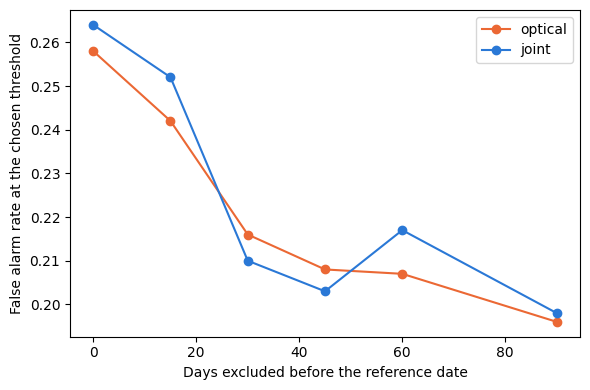

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
for m in MODES:
    s = sweep[sweep['mode'] == m]
    ax.plot(s.buffer, s.false_alarm, 'o-', color=COL[m], label=m)
ax.set_xlabel('Days excluded before the reference date')
ax.set_ylabel('False alarm rate at the chosen threshold')
ax.legend()
plt.tight_layout()

In [8]:
x = d['optical']
x = x[x.win == 'bef']
top = x.nlargest(40, 'p_dist')[['fid', 'date', 'days', 'p_dist', 'p_class']]
print(top.days.describe())
top.head(20)

count     40.000000
mean     -48.825000
std       46.768874
min     -202.000000
25%      -59.500000
50%      -32.000000
75%      -15.750000
max      -11.000000
Name: days, dtype: float64


,fid,date,days,p_dist,p_class
242,296,2023-06-04,-12,0.995171,0.899411
489,286,2023-04-30,-15,0.994948,0.958715
1963,80,2023-08-23,-21,0.994481,0.781061
64,350,2023-04-30,-142,0.994216,0.906521
240,296,2023-05-15,-32,0.993976,0.873860
65,350,2023-05-15,-127,0.993778,0.890538
1964,80,2023-08-28,-16,0.992922,0.754986
1103,108,2023-05-15,-14,0.992810,0.948820
67,350,2023-06-09,-102,0.991694,0.900349
2159,210,2023-07-29,-12,0.991540,0.823994


In [9]:
x = d['optical']
bef = x[x.win == 'bef']
print('todas las anteriores :', bef.days.describe()[['count','25%','50%','75%']].to_dict())
print('las 40 mayores       :', bef.nlargest(40, 'p_dist').days.describe()[['25%','50%','75%']].to_dict())

todas las anteriores : {'count': 1662.0, '25%': -96.0, '50%': -62.0, '75%': -32.0}
las 40 mayores       : {'25%': -59.5, '50%': -32.0, '75%': -15.75}


## 6. The two classifiers, on one common evaluation set

Sections 2 to 5 use one model at a time. This section compares the linear probe with the
random forest, and the two modes, on a single set of observations: the Sentinel-2 images
present in all four score sets.

Two reasons for the common set. First, average precision depends on the share of positives,
so comparing it across sets with different prevalence measures the prevalence and not the
model; `ap_over_baseline` divides it by that share to make the number readable. Second, the
four score sets do not otherwise contain the same acquisitions, and a difference in
coverage would be read as a difference in skill.

AUC is prevalence independent, so it is the number to quote when the sets differ.

In [ ]:
data = {}
for model in MODELS:
    for mode in MODES:
        data[(mode, model)] = load(mode, model=model)

keys = set.intersection(*(set(zip(x.fid, x.s2_id)) for x in data.values()))
print(f'Sentinel-2 images common to the four score sets: {len(keys)}')

rows = []
for (mode, model), x in data.items():
    c = curves(x, match=keys)
    i = int(np.argmax(c['tpr'] - c['fpr']))
    rows.append(dict(mode=mode, model=model, n=c['n'],
                     positives=round(c['pos'], 3),
                     auc=round(c['auc'], 3),
                     ap=round(c['ap'], 3),
                     ap_over_baseline=round(c['ap'] / c['pos'], 2),
                     tau=round(c['thr'][i], 3),
                     detection=round(c['tpr'][i], 3),
                     false_alarm=round(c['fpr'][i], 3)))

matched = pd.DataFrame(rows).sort_values(['mode', 'model']).reset_index(drop=True)
print()
print(matched.to_string(index=False))
print()
print('n and positives must be identical in the four rows; if not, the match failed.')

In [ ]:
# the operating points quoted in the write up, on the same common set
for target in [0.02, 0.05, 0.10]:
    print(f'--- false alarm rate {target:.0%}')
    for (mode, model), x in sorted(data.items()):
        c = curves(x, match=keys)
        i = min(int(np.searchsorted(c['fpr'], target)), len(c['thr']) - 1)
        print(f'  {mode:8s} {model:8s} tau {c["thr"][i]:.3f} '
              f'-> detection {c["tpr"][i]:.3f}')
    print()